In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [9]:
# import necessary layers  
from tensorflow.keras.layers import Input, Conv2D 
from tensorflow.keras.layers import MaxPool2D, Flatten, Dense 
from tensorflow.keras import Model
# input

input = Input(shape =(28,28,1))

# 1st Conv Block

x = Conv2D (filters =4, kernel_size =3, padding ='same', activation='relu')(input)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)

# 2nd Conv Block

x = Conv2D (filters =8, kernel_size =3, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)


x = Flatten()(x)
x = Dense(units = 8, activation ='relu')(x)
output = Dense(units = 10, activation ='softmax')(x)
# creating the model

model = Model (inputs=input, outputs =output)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 4)         40        
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 4)        0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 14, 14, 8)         296       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 7, 7, 8)          0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 392)               0   

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [11]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),  # Optimizer
    # Loss function to minimize
    loss=keras.losses.SparseCategoricalCrossentropy(),
    # List of metrics to monitor
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

In [12]:
print("Fit model on training data")
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=3,
)

Fit model on training data
Epoch 1/3
938/938 [==============================] - 7s 7ms/step - loss: 1.8058 - sparse_categorical_accuracy: 0.3557
Epoch 2/3
938/938 [==============================] - 7s 7ms/step - loss: 1.0774 - sparse_categorical_accuracy: 0.6133
Epoch 3/3
938/938 [==============================] - 7s 7ms/step - loss: 0.4957 - sparse_categorical_accuracy: 0.8720


In [13]:
import numpy
predictions = model.predict(x_test)
predicted_number = numpy.argmax(predictions, axis= 1)

matched = 0
not_matched = 0
for i in range(10000):
    if y_test[i] == predicted_number[i]:
        matched += 1
    else:
        not_matched += 1
print(f"matched numbers : {matched}")      
print(f"non matched numbers : {not_matched}")

313/313 [==============================] - 1s 2ms/step
matched numbers : 9193
non matched numbers : 807


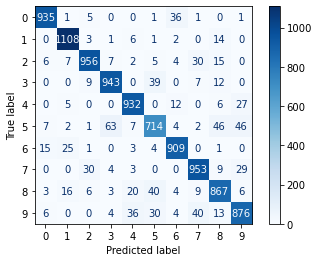

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

y_pred = predicted_number
y_test = y_test
labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues)
plt.savefig("confusion_matrix.jpg")
plt.show()

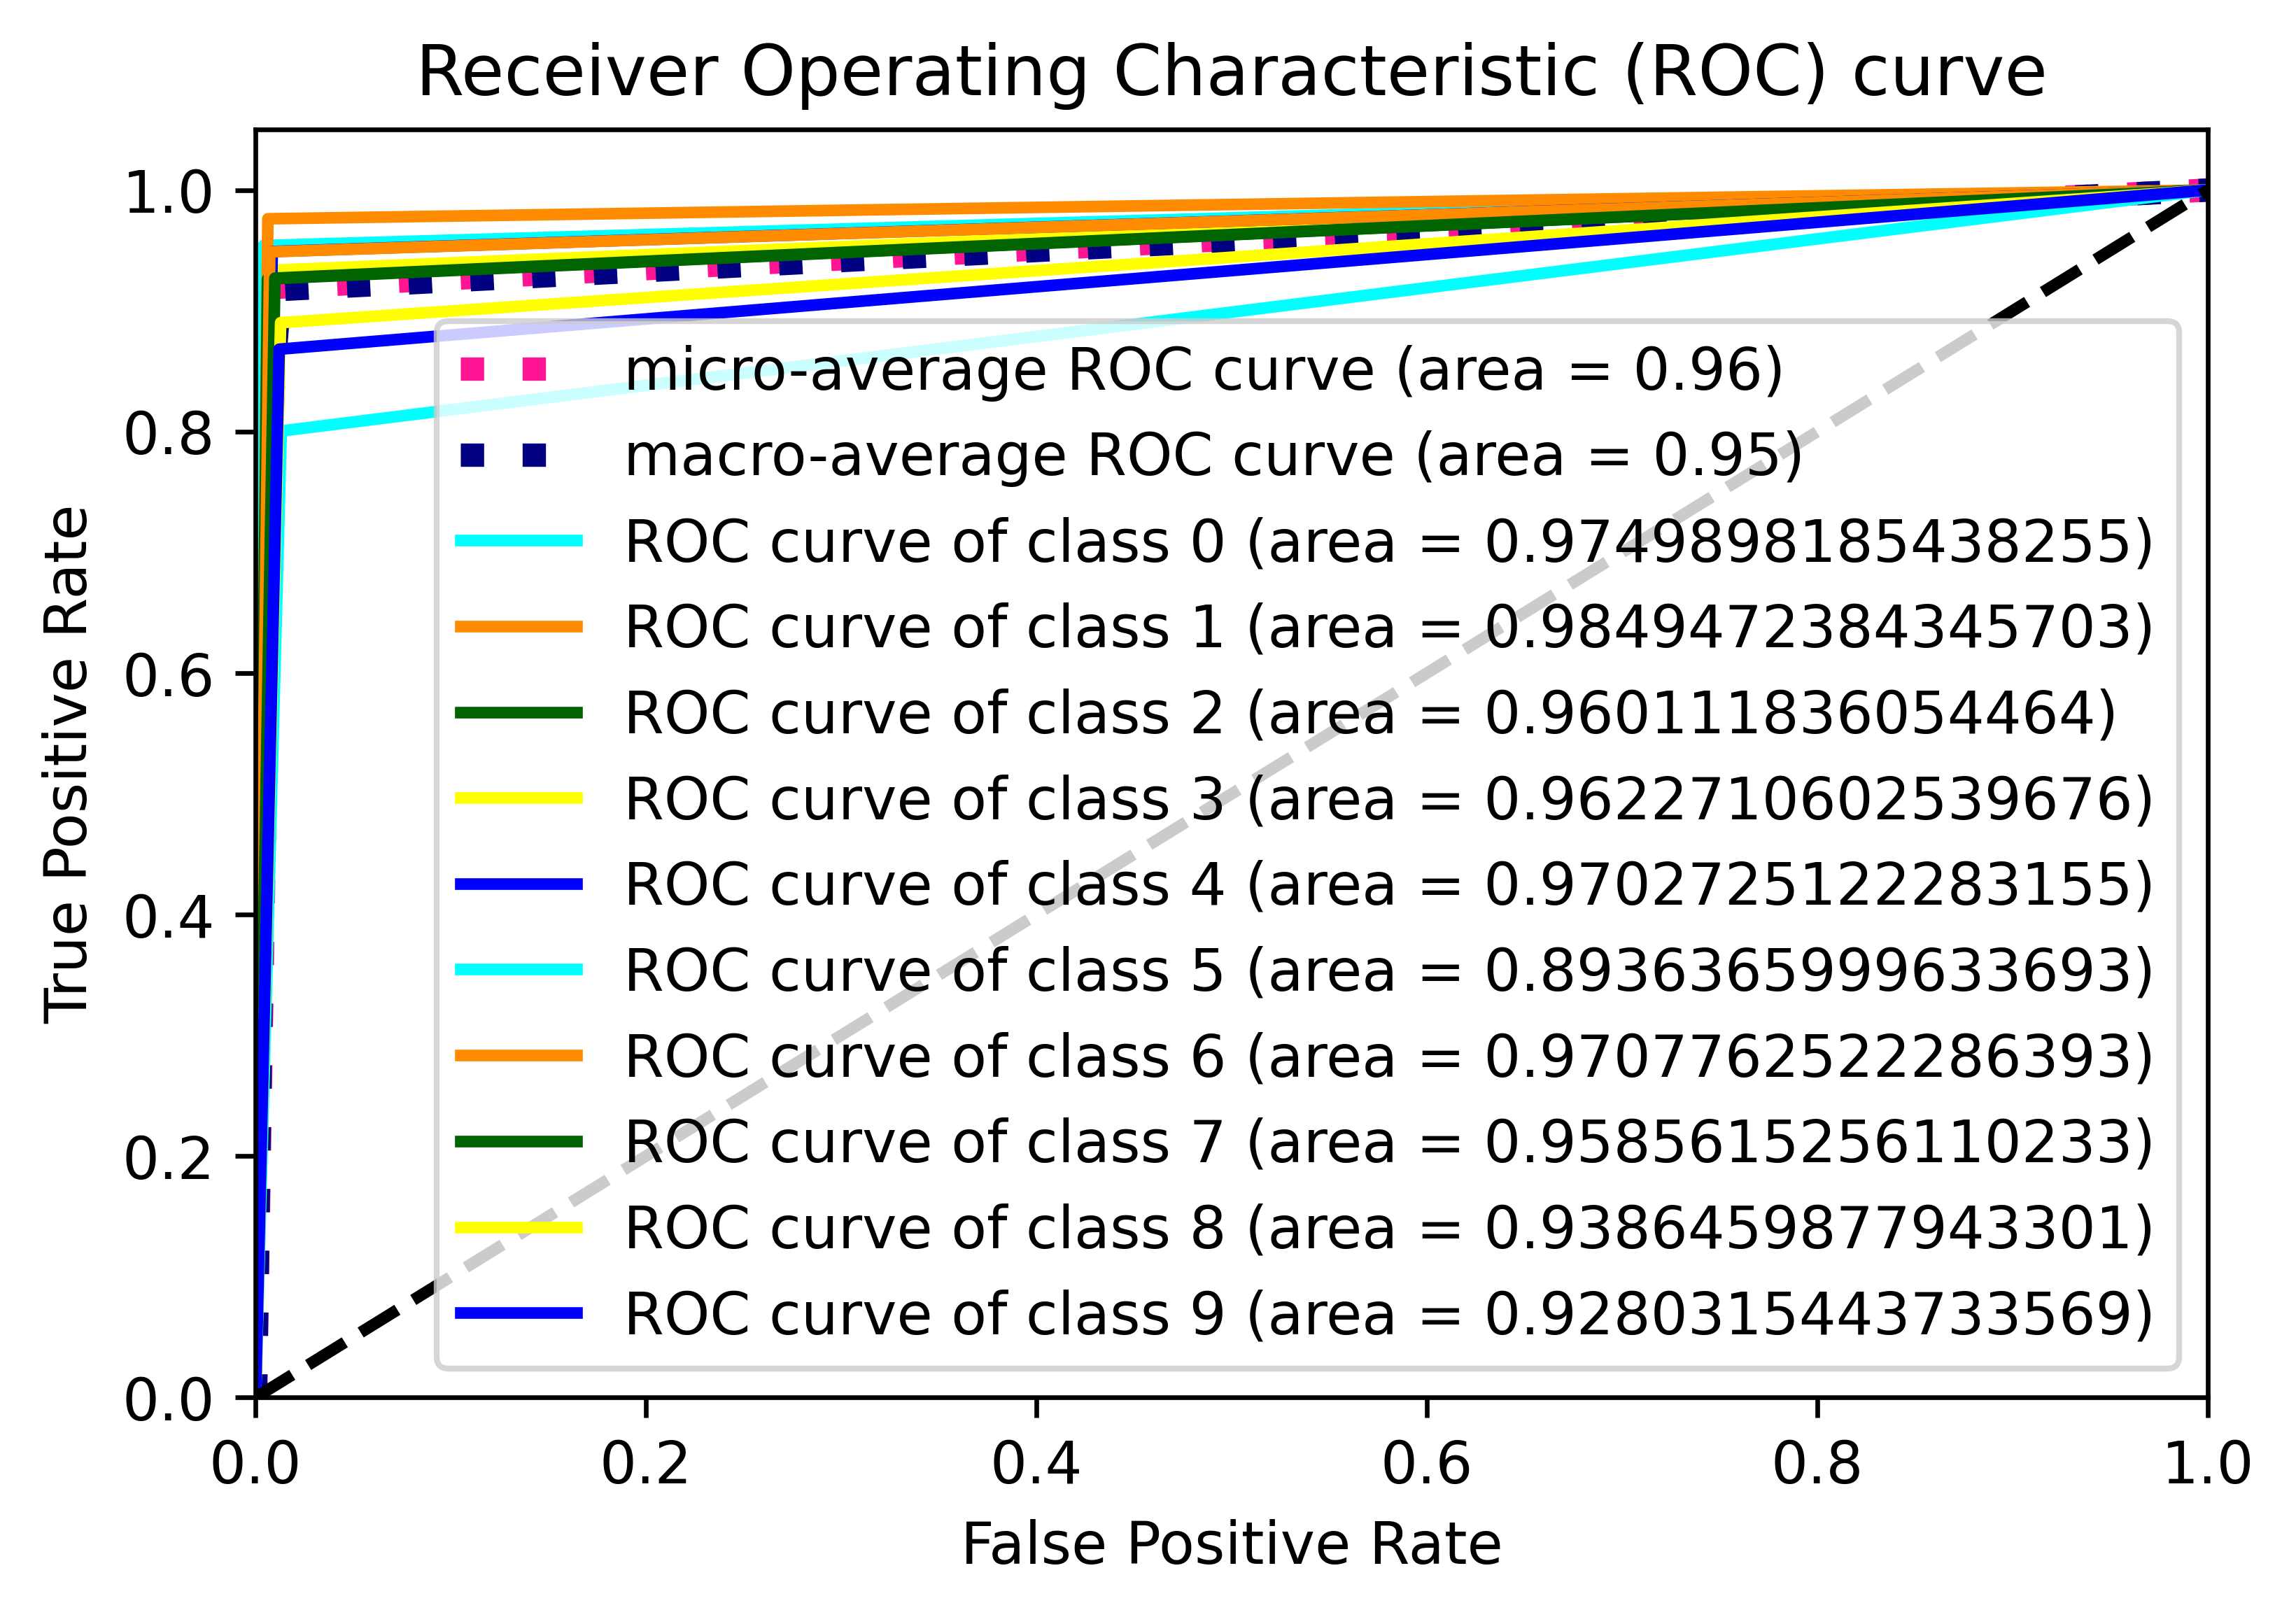

In [15]:

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize



n_classes = len(np.unique(y_test))
y_labelized_test = label_binarize(y_test, classes=np.arange(n_classes))
y_labelized_pred = label_binarize(predicted_number, classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
thresholds = dict()
for i in range(n_classes):
    fpr[i], tpr[i], thresholds[i] = roc_curve(y_labelized_test[:, i], y_labelized_pred[:, i], drop_intermediate=False)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_labelized_test.ravel(), y_labelized_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
#plt.figure(figsize=(10,5))
plt.figure(dpi=600)
lw = 2
plt.plot(fpr["micro"], tpr["micro"],
label="micro-average ROC curve (area = {0:0.2f})".format(roc_auc["micro"]),
color="deeppink", linestyle=":", linewidth=4,)

plt.plot(fpr["macro"], tpr["macro"],
label="macro-average ROC curve (area = {0:0.2f})".format(roc_auc["macro"]),
color="navy", linestyle=":", linewidth=4,)

colors = cycle(["aqua", "darkorange", "darkgreen", "yellow", "blue"])
for i, color in zip(range(n_classes), colors):
    #print(i, roc_auc)
    string_label = f"ROC curve of class {i} (area = {roc_auc[i]})"
    plt.plot(fpr[i], tpr[i], color=color, 
             lw=lw,label=string_label,)

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) curve")
plt.savefig("ROC2.jpg")
plt.legend()

In [31]:
# import necessary layers  
from tensorflow.keras.layers import Input, Conv2D 
from tensorflow.keras.layers import MaxPool2D, Flatten, Dense 
from tensorflow.keras import Model
# input

input = Input(shape =(28,28,1))

# 1st Conv Block

x = Conv2D (filters =3, kernel_size =5, padding ='same', activation='relu')(input)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)

# 2nd Conv Block

x = Conv2D (filters =6, kernel_size =5, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)


x = Flatten()(x)
x = Dense(units = 8, activation ='relu')(x)
output = Dense(units = 10, activation ='softmax')(x)
# creating the model

model = Model (inputs=input, outputs =output)
model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_8 (Conv2D)           (None, 28, 28, 3)         78        
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 14, 14, 3)        0         
 2D)                                                             
                                                                 
 conv2d_9 (Conv2D)           (None, 14, 14, 6)         456       
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 7, 7, 6)          0         
 2D)                                                             
                                                                 
 flatten_4 (Flatten)         (None, 294)               0   

In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [33]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),  # Optimizer
    # Loss function to minimize
    loss=keras.losses.SparseCategoricalCrossentropy(),
    # List of metrics to monitor
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

In [34]:
print("Fit model on training data")
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=2,
)

Fit model on training data
Epoch 1/2
938/938 [==============================] - 11s 11ms/step - loss: 2.1297 - sparse_categorical_accuracy: 0.1949
Epoch 2/2
938/938 [==============================] - 11s 12ms/step - loss: 1.9993 - sparse_categorical_accuracy: 0.2112


In [35]:
import numpy
predictions = model.predict(x_test)
predicted_number = numpy.argmax(predictions, axis= 1)

matched = 0
not_matched = 0
for i in range(10000):
    if y_test[i] == predicted_number[i]:
        matched += 1
    else:
        not_matched += 1
print(f"matched numbers : {matched}")      
print(f"non matched numbers : {not_matched}")

313/313 [==============================] - 1s 3ms/step
matched numbers : 2125
non matched numbers : 7875


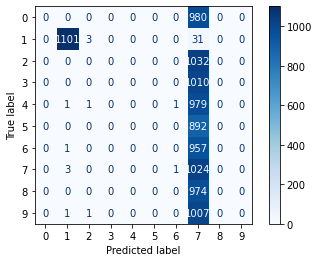

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

y_pred = predicted_number
y_test = y_test
labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues)
plt.savefig("confusion_matrix.jpg")
plt.show()

ROC curve of class 0 (area = 0.5)
ROC curve of class 1 (area = 0.9846836169562527)
ROC curve of class 2 (area = 0.49972123104371097)
ROC curve of class 3 (area = 0.5)
ROC curve of class 4 (area = 0.5)
ROC curve of class 5 (area = 0.5)
ROC curve of class 6 (area = 0.49988940499889406)
ROC curve of class 7 (area = 0.5599135919618493)
ROC curve of class 8 (area = 0.5)
ROC curve of class 9 (area = 0.5)


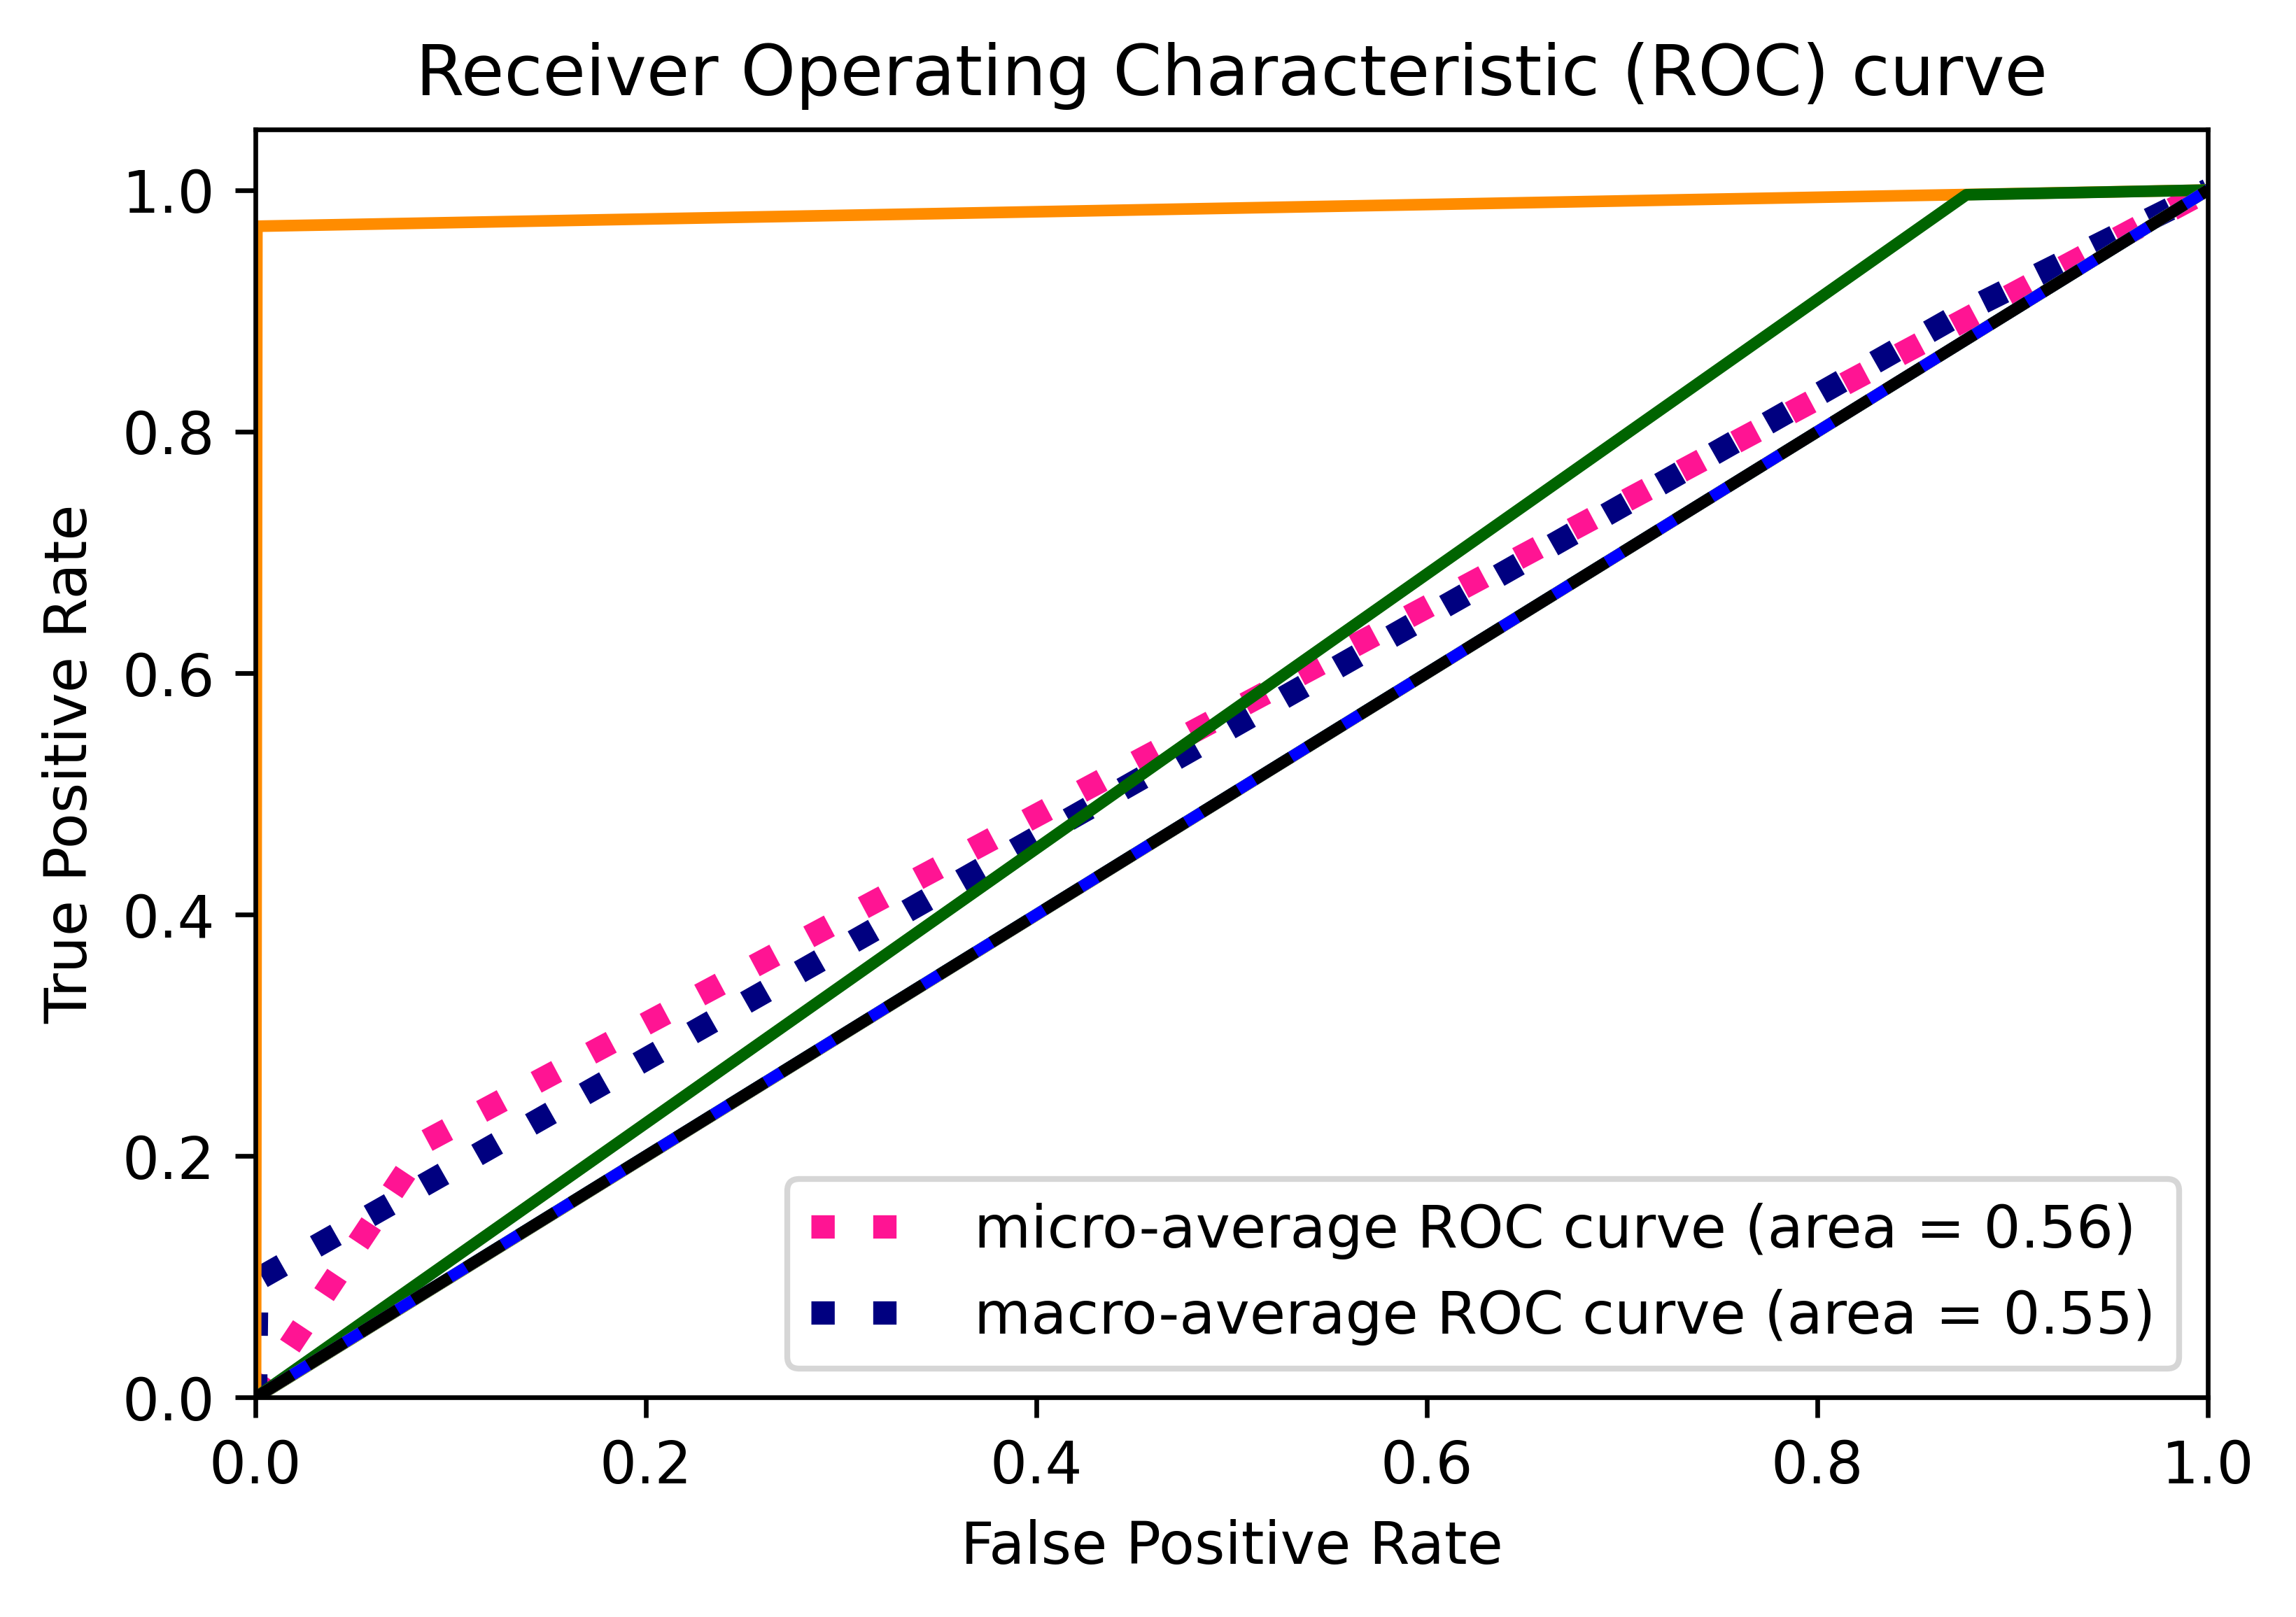

In [40]:

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize



n_classes = len(np.unique(y_test))
y_labelized_test = label_binarize(y_test, classes=np.arange(n_classes))
y_labelized_pred = label_binarize(predicted_number, classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
thresholds = dict()
for i in range(n_classes):
    fpr[i], tpr[i], thresholds[i] = roc_curve(y_labelized_test[:, i], y_labelized_pred[:, i], drop_intermediate=False)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_labelized_test.ravel(), y_labelized_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
#plt.figure(figsize=(10,5))
plt.figure(dpi=600)
lw = 2
plt.plot(fpr["micro"], tpr["micro"],
label="micro-average ROC curve (area = {0:0.2f})".format(roc_auc["micro"]),
color="deeppink", linestyle=":", linewidth=4,)

plt.plot(fpr["macro"], tpr["macro"],
label="macro-average ROC curve (area = {0:0.2f})".format(roc_auc["macro"]),
color="navy", linestyle=":", linewidth=4,)

colors = cycle(["aqua", "darkorange", "darkgreen", "yellow", "blue"])
for i, color in zip(range(n_classes), colors):
    #print(i, roc_auc)
    string_label = f"ROC curve of class {i} (area = {roc_auc[i]})"
    plt.plot(fpr[i], tpr[i], color=color, 
             lw=lw,)
    print(string_label)

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) curve")
plt.savefig("ROC2.jpg")
plt.legend()
